<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Enhanced SleepStageNet: Improved CNN, LSTM & Conformer for Sleep Stage Classification

**CSEP 590A Deep Learning — Group Project**

This notebook trains and evaluates **3 model architectures** for automatic sleep stage classification on the Sleep-EDF dataset:

| # | Model | Architecture | Key innovation |
|---|-------|-------------|----------------|
| 1 | `cnn_only` | Multi-scale CNN | Dual-path (fine + coarse filters) — improved baseline |
| 2 | `cnn_bilstm` | CNN + BiLSTM | Enhanced multi-scale CNN backbone, deeper LSTM |
| 3 | `conformer` | CNN + Conformer blocks | Attention + depthwise conv — best of both worlds |

### Improvements over baseline
- **Multi-scale CNN** backbone inspired by DeepSleepNet-Lite (small + large filter paths)
- **Focal loss** for handling severe N1 class imbalance
- **Label smoothing** + **Mixup augmentation** for regularization
- **Cosine annealing with warmup** for stable training
- **EEG data augmentation** (time shift, amplitude scaling, Gaussian noise)
- **3-stage training**: pretrain CNN → train temporal layers → fine-tune end-to-end

### HuggingFace models survey
We surveyed HuggingFace for pretrained EEG/sleep staging models. Current options are limited:
- `karnamgyal/sleep-stage-classifier` — CNN-LSTM, ~73% accuracy (lower than our baseline)
- `haseebnawazz/sleep-stage-classifier-model` — sklearn/joblib model, not deep learning
- `Soromis/BP-transformer-EEG` — Transformer for EEG, but for blood pressure estimation

The field primarily uses custom architectures: **SleepTransformer** (Phan et al., 2022), **L-SeqSleepNet** (Phan et al., 2023), **U-Sleep** (Perslev et al., 2021). Our Conformer model draws inspiration from these papers.

### Drive integration
All outputs (checkpoints, figures, results, training curves) are automatically saved to Google Drive.

**Runtime:** Select **GPU** (T4 or better) via `Runtime > Change runtime type`.

## 1. Environment Setup

In [2]:
# ===== 1a: Install dependencies & check GPU =====
!pip install -q torch torchvision torchaudio scikit-learn scipy matplotlib seaborn gdown

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU detected — training will be very slow. Go to Runtime > Change runtime type > GPU.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# ===== 1b: Mount Google Drive & set paths =====
import os, shutil
from google.colab import drive

drive.mount('/content/drive')

# ── Configure paths ──────────────────────────────────────────────
# This is the shared Google Drive folder that contains data/ already.
# Folder ID: 1S-RIIPcetbevDHsgY6hutbXkAKefsV5C
# Update DRIVE_BASE if your folder is mounted at a different path.
DRIVE_BASE = '/content/drive/MyDrive/SleepStageNet'

# Verify the folder exists
assert os.path.isdir(DRIVE_BASE), (
    f"Drive folder not found at {DRIVE_BASE}.\n"
    "Open the shared folder link in your browser, right-click > 'Add shortcut to Drive' > 'My Drive',\n"
    "then update DRIVE_BASE above to match the mounted path."
)

# Data paths (already on Drive)
DRIVE_DATA_DIR   = os.path.join(DRIVE_BASE, 'data', 'eeg_FpzCz_PzOz_v1')
DRIVE_SPLIT_PATH = os.path.join(DRIVE_BASE, 'data', 'data_split_v1.npz')

assert os.path.isdir(DRIVE_DATA_DIR), f"Data dir not found: {DRIVE_DATA_DIR}"
assert os.path.isfile(DRIVE_SPLIT_PATH), f"Split file not found: {DRIVE_SPLIT_PATH}"

# Output folder on Drive — everything gets saved here
DRIVE_ENHANCED = os.path.join(DRIVE_BASE, 'enhanced')
DRIVE_CKPT_DIR   = os.path.join(DRIVE_ENHANCED, 'checkpoints')
DRIVE_FIG_DIR    = os.path.join(DRIVE_ENHANCED, 'figures')
DRIVE_RESULT_DIR = os.path.join(DRIVE_ENHANCED, 'results')
DRIVE_CURVE_DIR  = os.path.join(DRIVE_ENHANCED, 'training_curves')

for d in [DRIVE_CKPT_DIR, DRIVE_FIG_DIR, DRIVE_RESULT_DIR, DRIVE_CURVE_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Drive base:   {DRIVE_BASE}")
print(f"Data dir:     {DRIVE_DATA_DIR}  ({len(os.listdir(DRIVE_DATA_DIR))} files)")
print(f"Split file:   {DRIVE_SPLIT_PATH}")
print(f"Enhanced out: {DRIVE_ENHANCED}")
print("✓ Drive mounted and paths verified.")

Mounted at /content/drive
Drive base:   /content/drive/MyDrive/SleepStageNet
Data dir:     /content/drive/MyDrive/SleepStageNet/data/eeg_FpzCz_PzOz_v1  (39 files)
Split file:   /content/drive/MyDrive/SleepStageNet/data/data_split_v1.npz
Enhanced out: /content/drive/MyDrive/SleepStageNet/enhanced
✓ Drive mounted and paths verified.


## 2. Code & Data Setup

Source code (`models.py`, `data_loader.py`, `train.py`) is read directly from Drive.  
Data is **copied** from Drive to the local Colab runtime for faster I/O during training.

In [4]:
# ===== 2a: Set up source code & copy data to local runtime =====
import os, shutil, glob, sys

# ── Source code: use enhanced/ directly from Drive ──
# The 3 Python files (models.py, data_loader.py, train.py) live on Drive
# under DRIVE_BASE/enhanced/. We create a local working copy.
DRIVE_CODE_DIR = os.path.join(DRIVE_BASE, 'enhanced')
LOCAL_WORK_DIR = '/content/enhanced'

os.makedirs(LOCAL_WORK_DIR, exist_ok=True)
for src_file in ['models.py', 'data_loader.py', 'train.py']:
    src = os.path.join(DRIVE_CODE_DIR, src_file)
    dst = os.path.join(LOCAL_WORK_DIR, src_file)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
        print(f"  Copied {src_file}")
    else:
        print(f"  ⚠️  {src_file} not found at {src}")

# ── Copy data from Drive to local runtime for faster I/O ──
LOCAL_DATA_DIR  = '/content/data/eeg_FpzCz_PzOz_v1'
LOCAL_SPLIT_PATH = '/content/data/data_split_v1.npz'

if not os.path.isdir(LOCAL_DATA_DIR):
    print("\nCopying data from Drive to local runtime (faster I/O)...")
    os.makedirs(os.path.dirname(LOCAL_DATA_DIR), exist_ok=True)
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    shutil.copy2(DRIVE_SPLIT_PATH, LOCAL_SPLIT_PATH)
    print("Data copied.")
else:
    print("\nLocal data already exists.")

npz_files = sorted(glob.glob(os.path.join(LOCAL_DATA_DIR, '*.npz')))
print(f"Data: {len(npz_files)} .npz files")

# ── Set environment variables & working directory ──
DATA_DIR_ABS   = os.path.abspath(LOCAL_DATA_DIR)
SPLIT_PATH_ABS = os.path.abspath(LOCAL_SPLIT_PATH)
os.environ['SLEEP_DATA_DIR']   = DATA_DIR_ABS
os.environ['SLEEP_SPLIT_PATH'] = SPLIT_PATH_ABS

os.chdir(LOCAL_WORK_DIR)
sys.path.insert(0, LOCAL_WORK_DIR)

print(f"\nDATA_DIR_ABS:   {DATA_DIR_ABS}")
print(f"SPLIT_PATH_ABS: {SPLIT_PATH_ABS}")
print(f"Working dir:    {os.getcwd()}")
!ls -la

  Copied models.py
  Copied data_loader.py
  Copied train.py

Copying data from Drive to local runtime (faster I/O)...
Data copied.
Data: 39 .npz files

DATA_DIR_ABS:   /content/data/eeg_FpzCz_PzOz_v1
SPLIT_PATH_ABS: /content/data/data_split_v1.npz
Working dir:    /content/enhanced
total 76
drwxr-xr-x 2 root root  4096 Mar  9 05:28 .
drwxr-xr-x 1 root root  4096 Mar  9 05:28 ..
-rw------- 1 root root 12076 Mar  8 06:46 data_loader.py
-rw------- 1 root root 27130 Mar  8 06:33 models.py
-rw------- 1 root root 25770 Mar  8 18:13 train.py


Number of .npz files: 39
Sample: x=(841, 3000, 2), y=(841,), fs=100.0 Hz


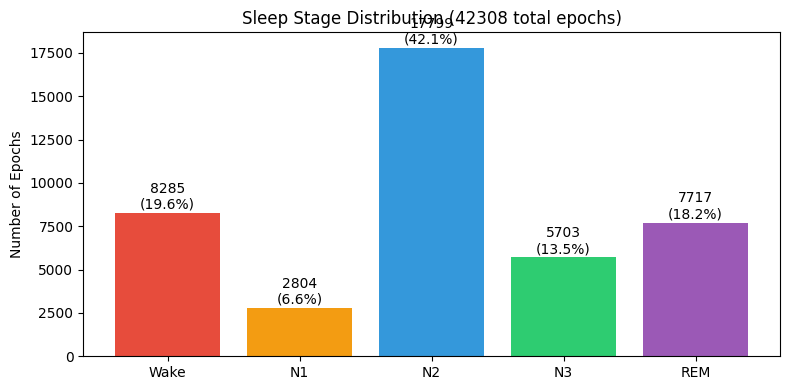


Class imbalance ratio (max/min): 6.3x
N1 is only 6.6% — motivates focal loss
Figure saved to Drive: /content/drive/MyDrive/SleepStageNet/enhanced/figures/class_distribution.png


In [4]:
# ===== 2b: Data sanity check + class distribution =====
import numpy as np
import matplotlib.pyplot as plt

data_files = sorted([f for f in os.listdir(DATA_DIR_ABS) if f.endswith('.npz')])
print(f"Number of .npz files: {len(data_files)}")

# Load and inspect one file
sample_file = os.path.join(DATA_DIR_ABS, data_files[0])
with np.load(sample_file) as f:
    x = f['x']; y = f['y']; fs = f['fs']
print(f"Sample: x={x.shape}, y={y.shape}, fs={fs} Hz")

# Class distribution
all_labels = np.concatenate([np.load(os.path.join(DATA_DIR_ABS, f))['y'] for f in data_files])
stage_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
counts = [np.sum(all_labels == i) for i in range(5)]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']
bars = ax.bar(stage_names, counts, color=colors)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count}\n({100*count/len(all_labels):.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of Epochs')
ax.set_title(f'Sleep Stage Distribution ({len(all_labels)} total epochs)')
plt.tight_layout()

# Save to Drive
fig.savefig(os.path.join(DRIVE_FIG_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio (max/min): {max(counts)/min(counts):.1f}x")
print(f"N1 is only {100*counts[1]/sum(counts):.1f}% — motivates focal loss")
print(f"Figure saved to Drive: {DRIVE_FIG_DIR}/class_distribution.png")

## 3. Model Architectures Overview

Let's inspect the available models and their parameter counts.

In [5]:
# ===== 3: Model architectures & parameter counts =====
import sys, torch
sys.path.insert(0, '.')

from models import MODEL_REGISTRY, MODEL_CONFIGS, build_model

print(f"{'Model':<20s} {'Params':>10s} {'Seq Len':>8s} {'Batch':>6s} {'Output':>12s}")
print('-' * 60)

B, L, C, T = 2, 11, 2, 3000
x_seq = torch.randn(B, L, C, T)
x_single = torch.randn(B, C, T)

for name in MODEL_REGISTRY:
    config = MODEL_CONFIGS[name]
    model = build_model(name, **config['model_kwargs'])
    n_params = sum(p.numel() for p in model.parameters())

    if name == 'cnn_only':
        out = model(x_single)
    else:
        out = model(x_seq)

    print(f'{name:<20s} {n_params:>10,} {config["seq_length"]:>8d} '
          f'{config["batch_size"]:>6d} {str(list(out.shape)):>12s}')
    del model

print(f'\nFor comparison: DeepSleepNet-Lite baseline has ~648K params')
print(f'                CNN+BiLSTM (temporal/) has ~345K params')

Model                    Params  Seq Len  Batch       Output
------------------------------------------------------------
cnn_only                190,661        1     64       [2, 5]
cnn_bilstm              850,757       11     32       [2, 5]
conformer             1,338,821       11     32       [2, 5]

For comparison: DeepSleepNet-Lite baseline has ~648K params
                CNN+BiLSTM (temporal/) has ~345K params


## 4. Training

### Training strategy
**3-stage training** for sequence models:
1. **CNN pre-training** on individual epochs (~50 epochs) — warm up the feature extractor
2. **Temporal training** with CNN frozen (~50 epochs) — train attention/LSTM on features
3. **End-to-end fine-tuning** with low LR (~30 epochs) — tune entire model jointly

### Key hyperparameter choices
| Parameter | Baseline (temporal/) | Enhanced |
|-----------|---------------------|----------|
| CNN | Single-path, 64-dim | **Multi-scale dual-path, 128-dim** |
| Seq length | 5 | **11-21** (more context) |
| Loss | CrossEntropy | **Focal Loss** (γ=2) + label smoothing |
| Augmentation | None | **Time shift, amplitude scale, noise, Mixup** |
| LR schedule | ReduceLROnPlateau | **Cosine annealing + warmup** |
| LSTM layers | 1 | **2** (for BiLSTM variants) |
| Dropout | 0.3 | **0.2-0.3** + residual dropout |

In [ ]:
# ===== Cell 4a: Quick test — train fold 0 of ONE model =====
# Change MODEL_NAME to test different architectures.
# Takes ~5-15 min on T4 depending on model.

MODEL_NAME = "conformer"  # Options: cnn_only, cnn_bilstm, conformer

!python train.py \
    --model {MODEL_NAME} \
    --fold 0 \
    --data_dir {DATA_DIR_ABS} \
    --split_path {SPLIT_PATH_ABS} \
    --cnn_epochs 30 \
    --temporal_epochs 30 \
    --finetune_epochs 20 \
    --output_dir output \
    --drive_ckpt_dir {DRIVE_CKPT_DIR}

print(f"\n✓ Checkpoint auto-saved to Drive after training.")


Fold 0 | model=conformer | seq_len=11 | device=cuda
batch_size=32 | lr=0.0003 | epochs=80 | focal=True | mixup=0.1

[1] Loading data...
  Train: 37701 | Val: 2269 | Test: 1948
  Class weights: [1.041 3.033 0.473 1.513 1.072]

[2] Stage 1: Pre-training CNN on individual epochs...
  [CNN pretrain] ep   1/30: loss=0.5248 acc=0.683 f1=0.652 | val loss=0.4037 acc=0.799 f1=0.761 κ=0.717 lr=1.0e-03 (13.6s) *
  [CNN pretrain] ep   5/30: loss=0.3881 acc=0.770 f1=0.740 | val loss=0.4955 acc=0.686 f1=0.686 κ=0.585 lr=1.0e-03 (11.6s)
  [CNN pretrain] ep   6/30: loss=0.3766 acc=0.773 f1=0.744 | val loss=0.3497 acc=0.823 f1=0.769 κ=0.739 lr=1.0e-03 (11.3s) *
  [CNN pretrain] ep  10/30: loss=0.3457 acc=0.789 f1=0.762 | val loss=0.3481 acc=0.822 f1=0.796 κ=0.748 lr=1.0e-03 (14.6s) *
  [CNN pretrain] ep  15/30: loss=0.3082 acc=0.809 f1=0.783 | val loss=0.3664 acc=0.768 f1=0.756 κ=0.680 lr=1.0e-03 (18.1s)
  [CNN pretrain] ep  20/30: loss=0.2450 acc=0.842 f1=0.823 | val loss=0.4059 acc=0.769 f1=0.749 κ=

In [10]:
# ===== Cell 4b: Train all 3 models on fold 0 for comparison =====
# ~20-40 min total on T4 GPU
# Each model's checkpoint is auto-uploaded to Drive via --drive_ckpt_dir

import os

MODELS_TO_TRAIN = ['cnn_only', 'cnn_bilstm', 'conformer']

for model_name in MODELS_TO_TRAIN:
    ckpt_dir = f'output/{model_name}'
    existing = [f for f in os.listdir(ckpt_dir)
                if f.startswith(f'{model_name}_fold0') or f.startswith('results_fold0')
                ] if os.path.isdir(ckpt_dir) else []
    if existing:
        print(f"\n{'='*60}")
        print(f"{model_name}: fold 0 already trained — skipping.")
        continue

    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")

    !python train.py \
        --model {model_name} \
        --fold 0 \
        --data_dir {DATA_DIR_ABS} \
        --split_path {SPLIT_PATH_ABS} \
        --output_dir output \
        --drive_ckpt_dir {DRIVE_CKPT_DIR}

print("\n✓ All 3 models trained on fold 0 & auto-saved to Drive!")


Training: cnn_only

Fold 0 | model=cnn_only | seq_len=1 | device=cuda
batch_size=64 | lr=0.001 | epochs=60 | focal=False | mixup=0.0

[1] Loading data...
  Train: 38051 | Val: 2289 | Test: 1968
  Class weights: [1.002 3.061 0.477 1.527 1.082]

  Model: cnn_only (190,661 params)

[2] Training CNN-only model...
  [Train] ep   1/60: loss=0.9774 acc=0.677 f1=0.635 | val loss=0.8544 acc=0.733 f1=0.729 κ=0.636 lr=2.0e-04 (9.4s) *
  [Train] ep   2/60: loss=0.8157 acc=0.778 f1=0.730 | val loss=0.7657 acc=0.823 f1=0.790 κ=0.747 lr=4.0e-04 (7.1s) *
  [Train] ep   5/60: loss=0.7516 acc=0.809 f1=0.764 | val loss=0.7262 acc=0.854 f1=0.800 κ=0.785 lr=1.0e-03 (8.5s) *
  [Train] ep   8/60: loss=0.7072 acc=0.823 f1=0.782 | val loss=0.6766 acc=0.863 f1=0.833 κ=0.800 lr=1.0e-03 (7.5s) *
  [Train] ep  10/60: loss=0.6875 acc=0.833 f1=0.795 | val loss=0.6959 acc=0.826 f1=0.802 κ=0.754 lr=9.9e-04 (7.7s)
  [Train] ep  15/60: loss=0.6471 acc=0.846 f1=0.811 | val loss=0.7208 acc=0.858 f1=0.812 κ=0.793 lr=9.4e-

In [6]:
# ===== Cell 4c: Full 20-fold CV for the best model =====
# Takes ~2-4 hours on T4.
# Checkpoints are auto-uploaded to Drive AFTER EACH FOLD (crash-resilient).

import os

BEST_MODEL = "conformer"  # Change after comparing fold 0 results

!python train.py \
    --model {BEST_MODEL} \
    --all_folds \
    --data_dir {DATA_DIR_ABS} \
    --split_path {SPLIT_PATH_ABS} \
    --output_dir output \
    --drive_ckpt_dir {DRIVE_CKPT_DIR}

print(f"\n✓ All 20-fold checkpoints for {BEST_MODEL} saved to Drive: {DRIVE_CKPT_DIR}/{BEST_MODEL}")

Restored 80 file(s) from Drive: /content/drive/MyDrive/SleepStageNet/enhanced/checkpoints/conformer

Fold 0 already complete — loaded from output/conformer/results_fold0.json
  test_acc=0.8650  test_f1=0.8093  test_κ=0.8238

Fold 1 already complete — loaded from output/conformer/results_fold1.json
  test_acc=0.8585  test_f1=0.8204  test_κ=0.7946

Fold 2 already complete — loaded from output/conformer/results_fold2.json
  test_acc=0.8203  test_f1=0.7966  test_κ=0.7531

Fold 3 already complete — loaded from output/conformer/results_fold3.json
  test_acc=0.8676  test_f1=0.8119  test_κ=0.8122

Fold 4 already complete — loaded from output/conformer/results_fold4.json
  test_acc=0.8182  test_f1=0.8009  test_κ=0.7498

Fold 5 already complete — loaded from output/conformer/results_fold5.json
  test_acc=0.8820  test_f1=0.8370  test_κ=0.8379

Fold 6 already complete — loaded from output/conformer/results_fold6.json
  test_acc=0.8880  test_f1=0.8622  test_κ=0.8473

Fold 7 already complete — loade

## 5. Full 20-Fold Cross-Validation Comparison
Load all completed fold results from Google Drive and build a comprehensive comparison dashboard for **CNN-BiLSTM** and **Conformer** across 20 leave-one-subject-out folds.

In [5]:
# ===== 5f-1: Load all 20-fold results from Drive =====
import json, os, glob, shutil
import numpy as np
import pandas as pd

MODELS_CV = ['cnn_bilstm', 'conformer']
N_FOLDS = 20

# ── Copy results from Drive → local output/ ──
for model_name in MODELS_CV:
    src_dir = os.path.join(DRIVE_CKPT_DIR, model_name)
    dst_dir = os.path.join('output', model_name)
    os.makedirs(dst_dir, exist_ok=True)
    if os.path.isdir(src_dir):
        for fname in os.listdir(src_dir):
            src_f = os.path.join(src_dir, fname)
            dst_f = os.path.join(dst_dir, fname)
            if os.path.isfile(src_f) and not os.path.exists(dst_f):
                shutil.copy2(src_f, dst_f)
        print(f"✓ Synced {model_name}: {len(os.listdir(src_dir))} files on Drive → local")
    else:
        print(f"⚠ Drive dir not found: {src_dir}")

# ── Parse results & history JSONs ──
results_all = {}   # model → list of dicts
history_all = {}   # model → list of dicts

for model_name in MODELS_CV:
    results_all[model_name] = []
    history_all[model_name] = []
    for fold in range(N_FOLDS):
        # Results
        rpath = f'output/{model_name}/results_fold{fold}.json'
        if os.path.exists(rpath):
            with open(rpath) as f:
                results_all[model_name].append(json.load(f))
        else:
            print(f"  Missing: {rpath}")
        # History
        hpath = f'output/{model_name}/history_fold{fold}.json'
        if os.path.exists(hpath):
            with open(hpath) as f:
                history_all[model_name].append(json.load(f))

for m in MODELS_CV:
    n = len(results_all[m])
    print(f"\n{m}: {n}/{N_FOLDS} fold results loaded")
    if n > 0:
        accs = [r['test_accuracy'] for r in results_all[m]]
        f1s  = [r['test_f1_macro'] for r in results_all[m]]
        print(f"  Test Acc:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
        print(f"  Test F1m:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

✓ Synced cnn_bilstm: 80 files on Drive → local
✓ Synced conformer: 80 files on Drive → local

cnn_bilstm: 20/20 fold results loaded
  Test Acc:  0.8410 ± 0.0655
  Test F1m:  0.7905 ± 0.0668

conformer: 20/20 fold results loaded
  Test Acc:  0.8292 ± 0.0742
  Test F1m:  0.7795 ± 0.0736


In [6]:
# ===== 5f-2: Per-fold results table =====
import pandas as pd, numpy as np

METRICS = ['test_accuracy', 'test_f1_macro', 'test_f1_weighted', 'test_kappa']
METRIC_LABELS = {'test_accuracy': 'Accuracy', 'test_f1_macro': 'F1 (macro)',
                 'test_f1_weighted': 'F1 (weighted)', 'test_kappa': 'Cohen κ'}

rows = []
for model_name in MODELS_CV:
    for r in results_all[model_name]:
        row = {'Model': model_name, 'Fold': r['fold']}
        for m in METRICS:
            row[METRIC_LABELS[m]] = r[m]
        rows.append(row)

df_folds = pd.DataFrame(rows)

# ── Summary statistics ──
summary_rows = []
for model_name in MODELS_CV:
    sub = df_folds[df_folds['Model'] == model_name]
    row = {'Model': model_name, 'Fold': 'Mean ± Std'}
    for m in METRICS:
        col = METRIC_LABELS[m]
        row[col] = f"{sub[col].mean():.4f} ± {sub[col].std():.4f}"
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

print("=" * 80)
print("PER-FOLD TEST METRICS")
print("=" * 80)
# Format numeric columns
display_df = df_folds.copy()
for col in ['Accuracy', 'F1 (macro)', 'F1 (weighted)', 'Cohen κ']:
    display_df[col] = display_df[col].map(lambda x: f"{x:.4f}")

# Pivot so models are side by side
for model_name in MODELS_CV:
    print(f"\n── {model_name} ──")
    sub = display_df[display_df['Model'] == model_name].drop(columns='Model')
    print(sub.to_string(index=False))

print("\n" + "=" * 80)
print("AGGREGATE (mean ± std across 20 folds)")
print("=" * 80)
print(df_summary.to_string(index=False))

# Save to Drive
csv_path = os.path.join(DRIVE_RESULT_DIR, 'cv20_per_fold_results.csv')
df_folds.to_csv(csv_path, index=False)
print(f"\n✓ Saved per-fold results to {csv_path}")

PER-FOLD TEST METRICS

── cnn_bilstm ──
 Fold Accuracy F1 (macro) F1 (weighted) Cohen κ
    0   0.8573     0.8057        0.8596  0.8145
    1   0.8872     0.8553        0.8898  0.8341
    2   0.8505     0.8400        0.8488  0.7910
    3   0.8681     0.8076        0.8777  0.8129
    4   0.8431     0.8227        0.8475  0.7815
    5   0.8862     0.8567        0.8948  0.8450
    6   0.9010     0.8793        0.9029  0.8652
    7   0.9098     0.8639        0.9072  0.8806
    8   0.8150     0.7189        0.8054  0.7560
    9   0.8263     0.7746        0.8372  0.7528
   10   0.8722     0.7733        0.8838  0.7980
   11   0.6380     0.6225        0.6631  0.5176
   12   0.7870     0.7431        0.7975  0.7144
   13   0.8487     0.8090        0.8561  0.7927
   14   0.9112     0.8246        0.9195  0.8784
   15   0.9172     0.8396        0.9180  0.8878
   16   0.7889     0.7378        0.8122  0.7151
   17   0.7347     0.6473        0.7388  0.6482
   18   0.8133     0.7858        0.8210  0.7574


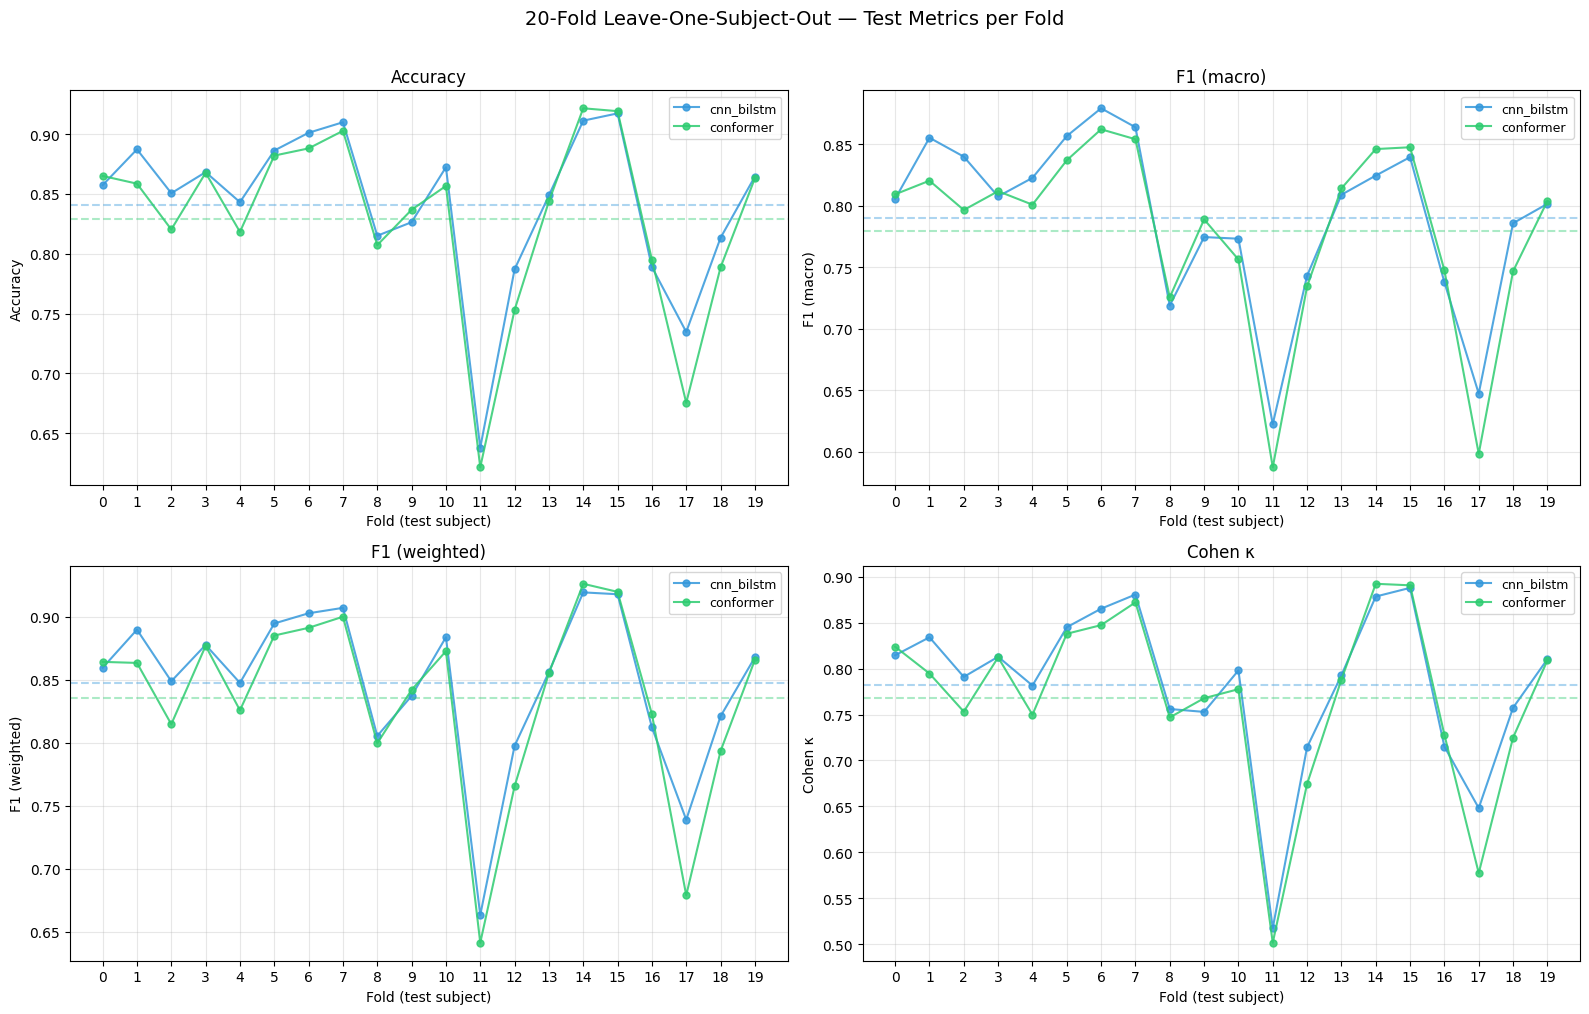

✓ Saved to /content/drive/MyDrive/SleepStageNet/enhanced/figures/cv20_per_fold_metrics.png


In [7]:
# ===== 5f-3: Per-fold metric line plots =====
import matplotlib.pyplot as plt
import numpy as np

COLORS = {'cnn_bilstm': '#3498db', 'conformer': '#2ecc71'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
folds_x = np.arange(N_FOLDS)

for idx, (metric, label) in enumerate(METRIC_LABELS.items()):
    ax = axes.flat[idx]
    for model_name in MODELS_CV:
        vals = [r[metric] for r in sorted(results_all[model_name], key=lambda x: x['fold'])]
        ax.plot(folds_x, vals, 'o-', color=COLORS[model_name], label=model_name,
                markersize=5, linewidth=1.5, alpha=0.85)
        ax.axhline(np.mean(vals), color=COLORS[model_name], linestyle='--', alpha=0.4)
    ax.set_xlabel('Fold (test subject)')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(folds_x)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('20-Fold Leave-One-Subject-Out — Test Metrics per Fold', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(DRIVE_FIG_DIR, 'cv20_per_fold_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {DRIVE_FIG_DIR}/cv20_per_fold_metrics.png")

/tmp/ipykernel_475/2028421663.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,
/tmp/ipykernel_475/2028421663.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,
/tmp/ipykernel_475/2028421663.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,
/tmp/ipykernel_475/2028421663.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name wil

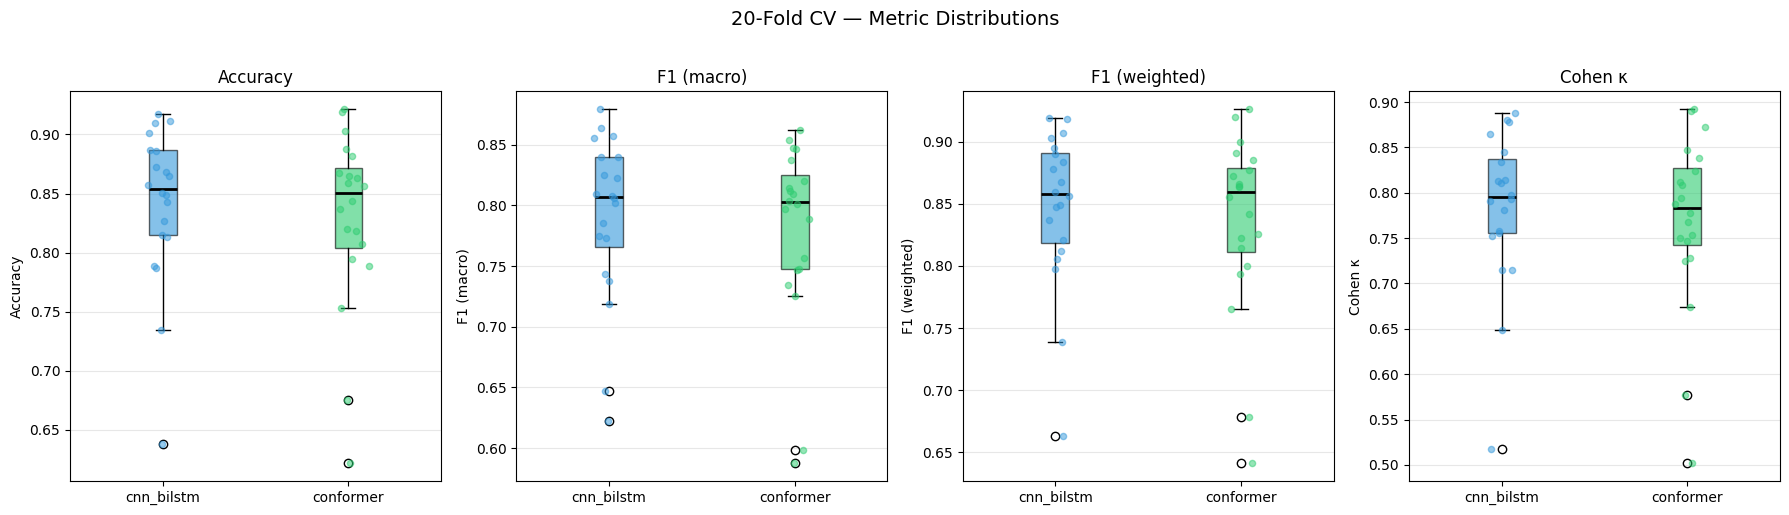

✓ Saved to /content/drive/MyDrive/SleepStageNet/enhanced/figures/cv20_boxplots.png


In [8]:
# ===== 5f-4: Box plots — metric distributions across folds =====
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for idx, (metric, label) in enumerate(METRIC_LABELS.items()):
    ax = axes[idx]
    data_box = []
    labels_box = []
    for model_name in MODELS_CV:
        vals = [r[metric] for r in results_all[model_name]]
        data_box.append(vals)
        labels_box.append(model_name)

    bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, model_name in zip(bp['boxes'], MODELS_CV):
        patch.set_facecolor(COLORS[model_name])
        patch.set_alpha(0.6)

    # Overlay individual points
    for i, (model_name, vals) in enumerate(zip(MODELS_CV, data_box)):
        jitter = np.random.normal(0, 0.04, size=len(vals))
        ax.scatter([i + 1 + jitter[j] for j in range(len(vals))], vals,
                   color=COLORS[model_name], alpha=0.5, s=20, zorder=3)

    ax.set_title(label)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('20-Fold CV — Metric Distributions', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(DRIVE_FIG_DIR, 'cv20_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {DRIVE_FIG_DIR}/cv20_boxplots.png")


cnn_bilstm: evaluated 20/20 folds

conformer: evaluated 20/20 folds


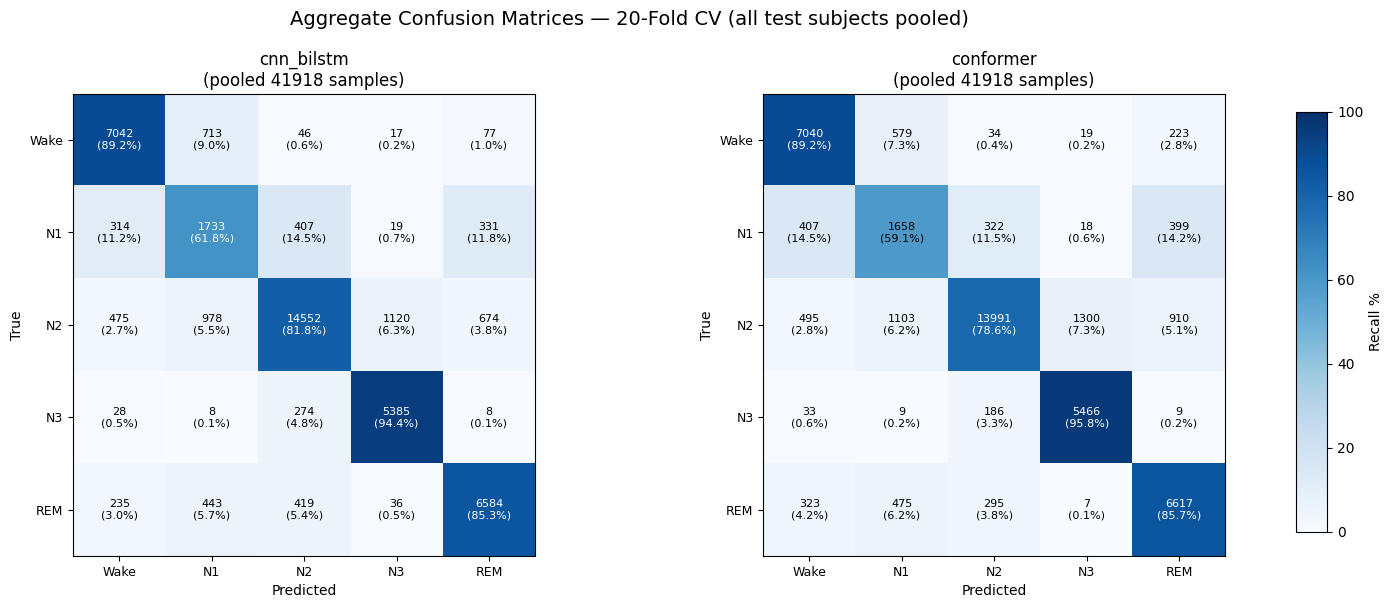


Classification Report — cnn_bilstm (all 20 folds pooled)
              precision    recall  f1-score   support

        Wake     0.8700    0.8920    0.8809      7895
          N1     0.4472    0.6180    0.5189      2804
          N2     0.9270    0.8176    0.8689     17799
          N3     0.8188    0.9442    0.8770      5703
         REM     0.8580    0.8532    0.8556      7717

    accuracy                         0.8420     41918
   macro avg     0.7842    0.8250    0.8003     41918
weighted avg     0.8567    0.8420    0.8464     41918


Classification Report — conformer (all 20 folds pooled)
              precision    recall  f1-score   support

        Wake     0.8484    0.8917    0.8695      7895
          N1     0.4336    0.5913    0.5003      2804
          N2     0.9436    0.7861    0.8576     17799
          N3     0.8026    0.9584    0.8737      5703
         REM     0.8111    0.8575    0.8336      7717

    accuracy                         0.8295     41918
   macro avg    

In [15]:
# ===== 5f-5: Aggregate confusion matrices (all 20 folds pooled) =====
import matplotlib.pyplot as plt
import numpy as np
import torch, os
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from torch.utils.data import DataLoader
import sys
sys.path.insert(0, '.')
from data_loader import STAGE_NAMES  # W, N1, N2, N3, REM

# We need to reload models & re-evaluate to get per-sample predictions.
# Strategy: Load each fold's best checkpoint, run evaluate on test split.

from models import build_model, MODEL_CONFIGS
from data_loader import get_fold_data
from train import evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

agg_cm = {}
agg_true = {}
agg_preds = {}

for model_name in MODELS_CV:
    all_true, all_preds_list = [], []
    cfg = MODEL_CONFIGS[model_name]
    seq_length = cfg['seq_length']
    n_success = 0

    for fold in range(N_FOLDS):
        # Correct checkpoint filename: {model_name}_fold{N}_L{seq_length}.pt
        ckpt_path = f'output/{model_name}/{model_name}_fold{fold}_L{seq_length}.pt'
        if not os.path.exists(ckpt_path):
            print(f"  Skip {model_name} fold {fold}: no checkpoint")
            continue

        # Build model & load weights
        model = build_model(model_name, **cfg['model_kwargs'])
        model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
        model.to(device)
        model.eval()

        # Get test data (7-tuple: train_recs, val_recs, test_recs, train_ds, val_ds, test_ds, class_weights)
        _, _, _, _, _, test_ds, _ = get_fold_data(
            fold, seq_length, DATA_DIR_ABS, SPLIT_PATH_ABS, augment_train=False
        )
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

        # Evaluate
        criterion = torch.nn.CrossEntropyLoss()
        eval_res = evaluate(model, test_loader, criterion, device)
        all_true.extend(eval_res['true'])
        all_preds_list.extend(eval_res['preds'])
        n_success += 1
        del model
        torch.cuda.empty_cache()

    print(f"\n{model_name}: evaluated {n_success}/{N_FOLDS} folds")
    if len(all_true) > 0:
        agg_true[model_name] = np.array(all_true)
        agg_preds[model_name] = np.array(all_preds_list)
        agg_cm[model_name] = confusion_matrix(all_true, all_preds_list, labels=range(5))

# ── Plot side-by-side confusion matrices ──
n_models = len(agg_cm)
if n_models == 0:
    print("⚠ No confusion matrices to plot (no checkpoints found).")
else:
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models + 1.5, 6),
                             gridspec_kw={'wspace': 0.35})
    if n_models == 1:
        axes = [axes]

    for ax, model_name in zip(axes, agg_cm):
        cm = agg_cm[model_name]
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

        im = ax.imshow(cm_pct, interpolation='nearest', cmap='Blues', vmin=0, vmax=100)
        ax.set_title(f'{model_name}\n(pooled {cm.sum()} samples)', fontsize=12)
        ax.set_xticks(range(5)); ax.set_xticklabels(STAGE_NAMES, fontsize=9)
        ax.set_yticks(range(5)); ax.set_yticklabels(STAGE_NAMES, fontsize=9)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')

        # Annotate cells with count + percentage
        for i in range(5):
            for j in range(5):
                txt = f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)"
                color = 'white' if cm_pct[i, j] > 60 else 'black'
                ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

    plt.suptitle('Aggregate Confusion Matrices — 20-Fold CV (all test subjects pooled)',
                 fontsize=14, y=1.02)
    # Place colorbar to the right, outside the subplots
    cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Recall %')
    fig.subplots_adjust(right=0.90)
    fig.savefig(os.path.join(DRIVE_FIG_DIR, 'cv20_confusion_matrices.png'), dpi=150, bbox_inches='tight')
    plt.show()

# ── Print classification reports ──
for model_name in agg_cm:
    print(f"\n{'='*60}")
    print(f"Classification Report — {model_name} (all 20 folds pooled)")
    print('='*60)
    print(classification_report(agg_true[model_name], agg_preds[model_name],
                                target_names=STAGE_NAMES, digits=4))

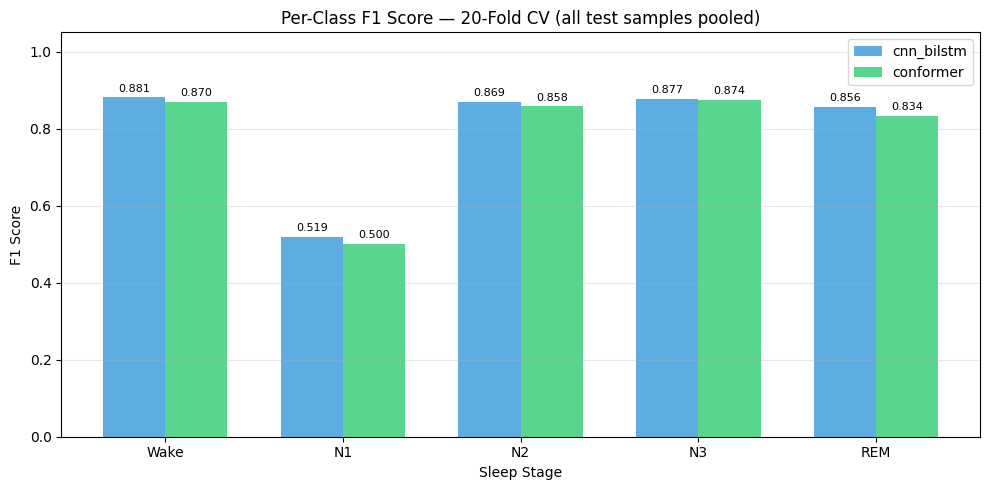

✓ Saved to /content/drive/MyDrive/SleepStageNet/enhanced/figures/cv20_per_class_f1.png


In [16]:
# ===== 5f-6: Per-class F1 comparison (pooled) =====
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(STAGE_NAMES))
bar_width = 0.35

for i, model_name in enumerate(MODELS_CV):
    if model_name not in agg_true:
        continue
    per_class_f1 = f1_score(agg_true[model_name], agg_preds[model_name],
                            labels=range(5), average=None)
    bars = ax.bar(x + i * bar_width, per_class_f1, bar_width,
                  label=model_name, color=COLORS[model_name], alpha=0.8)
    # Add text labels on bars
    for bar, val in zip(bars, per_class_f1):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Sleep Stage')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score — 20-Fold CV (all test samples pooled)')
ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(STAGE_NAMES)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig(os.path.join(DRIVE_FIG_DIR, 'cv20_per_class_f1.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {DRIVE_FIG_DIR}/cv20_per_class_f1.png")

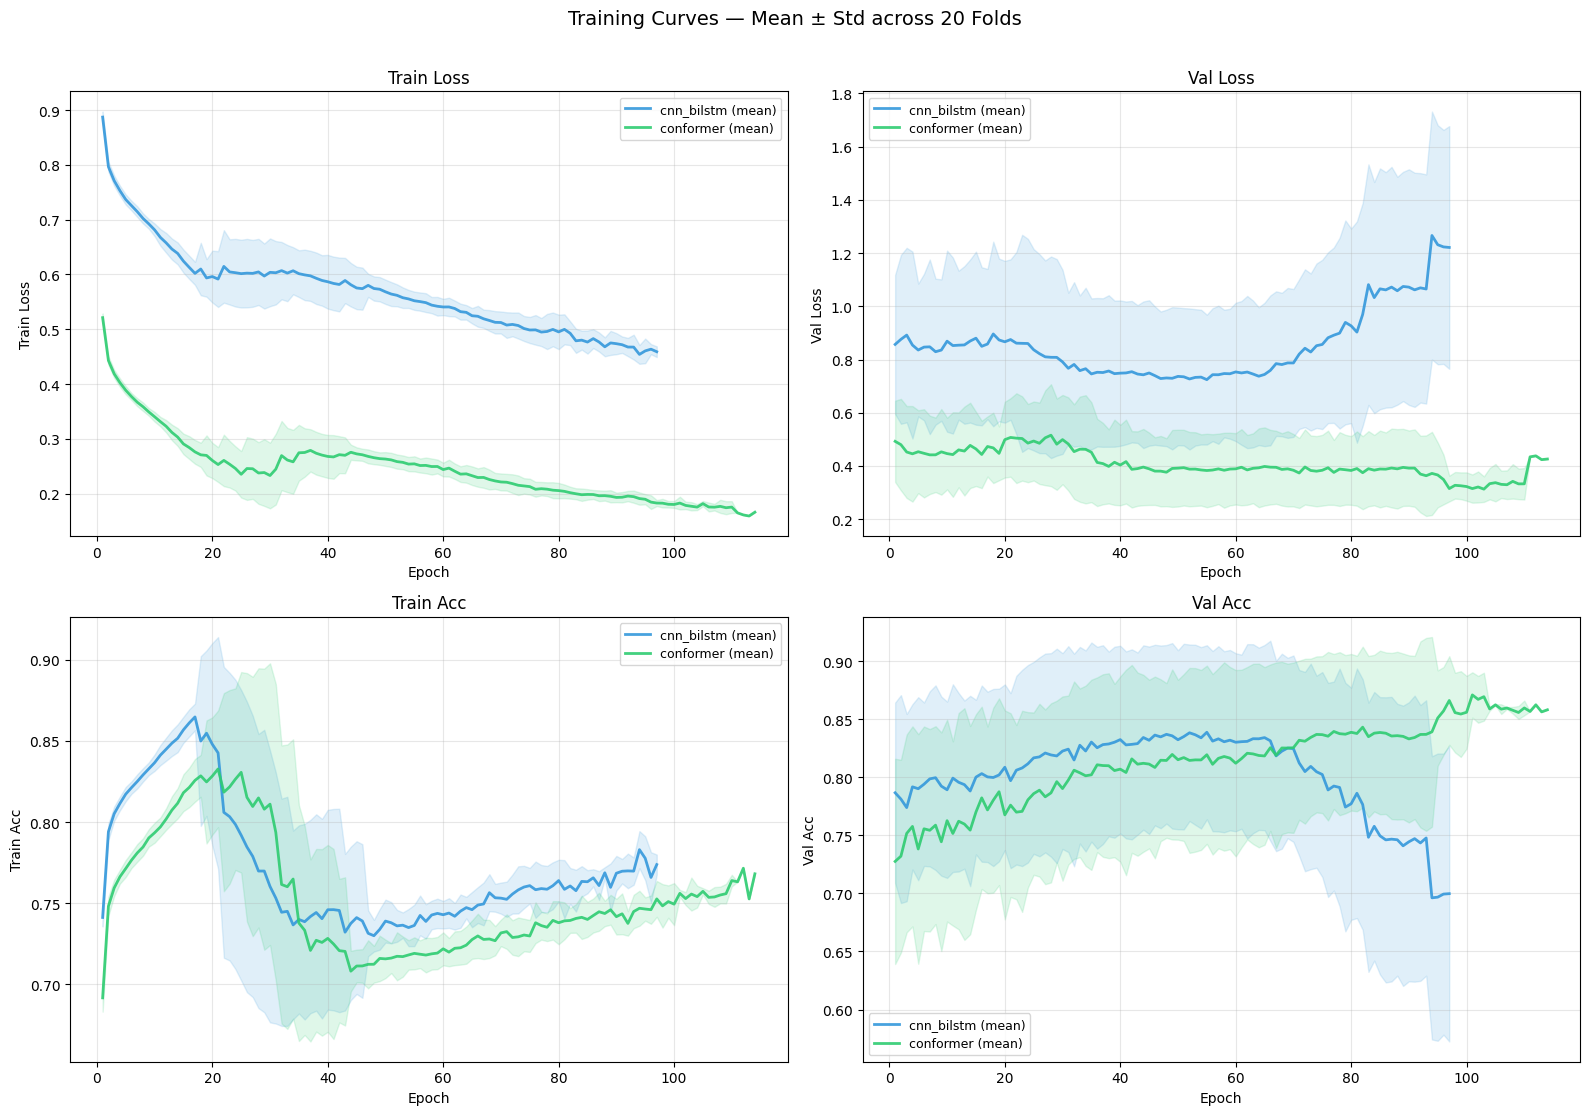

✓ Saved to /content/drive/MyDrive/SleepStageNet/enhanced/training_curves/cv20_training_curves_avg.png


In [17]:
# ===== 5f-7: Training curves — averaged across folds + individual envelopes =====
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
curve_keys = [('train_loss', 'Train Loss'), ('val_loss', 'Val Loss'),
              ('train_acc', 'Train Acc'), ('val_acc', 'Val Acc')]

for model_name in MODELS_CV:
    histories = history_all[model_name]
    if not histories:
        continue
    color = COLORS[model_name]

    for ax, (key, title) in zip(axes.flat, curve_keys):
        # Collect curves of varying lengths → pad with NaN and compute mean/std
        curves = [np.array(h[key]) for h in histories if key in h and len(h[key]) > 0]
        if not curves:
            continue
        max_len = max(len(c) for c in curves)
        padded = np.full((len(curves), max_len), np.nan)
        for i, c in enumerate(curves):
            padded[i, :len(c)] = c

        mean_curve = np.nanmean(padded, axis=0)
        std_curve = np.nanstd(padded, axis=0)
        epochs = np.arange(1, max_len + 1)

        ax.plot(epochs, mean_curve, '-', color=color, linewidth=2,
                label=f'{model_name} (mean)', alpha=0.9)
        ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                        color=color, alpha=0.15)

for ax, (key, title) in zip(axes.flat, curve_keys):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Training Curves — Mean ± Std across 20 Folds', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(DRIVE_CURVE_DIR, 'cv20_training_curves_avg.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {DRIVE_CURVE_DIR}/cv20_training_curves_avg.png")

In [18]:
# ===== 5f-8: Statistical comparison — paired tests =====
import numpy as np
from scipy import stats

print("=" * 70)
print("STATISTICAL COMPARISON: CNN-BiLSTM vs Conformer (paired, 20 folds)")
print("=" * 70)

# Align results by fold
bilstm_by_fold = {r['fold']: r for r in results_all['cnn_bilstm']}
conf_by_fold   = {r['fold']: r for r in results_all['conformer']}
common_folds = sorted(set(bilstm_by_fold) & set(conf_by_fold))
print(f"Common folds: {len(common_folds)}")

for metric, label in METRIC_LABELS.items():
    a = np.array([bilstm_by_fold[f][metric] for f in common_folds])
    b = np.array([conf_by_fold[f][metric]   for f in common_folds])
    diff = a - b

    # Paired t-test
    t_stat, t_pval = stats.ttest_rel(a, b)
    # Wilcoxon signed-rank test (non-parametric)
    try:
        w_stat, w_pval = stats.wilcoxon(a, b)
    except ValueError:
        w_stat, w_pval = np.nan, np.nan  # all differences zero

    winner = 'cnn_bilstm' if np.mean(diff) > 0 else 'conformer'
    print(f"\n── {label} ──")
    print(f"  cnn_bilstm : {np.mean(a):.4f} ± {np.std(a):.4f}")
    print(f"  conformer  : {np.mean(b):.4f} ± {np.std(b):.4f}")
    print(f"  Δ (bilstm-conf): {np.mean(diff):+.4f} ± {np.std(diff):.4f}")
    print(f"  Paired t-test:  t={t_stat:+.3f}, p={t_pval:.4f} {'*' if t_pval < 0.05 else ''}")
    print(f"  Wilcoxon:       W={w_stat:.0f}, p={w_pval:.4f} {'*' if w_pval < 0.05 else ''}")
    print(f"  → {'No significant difference' if t_pval >= 0.05 else f'{winner} significantly better'} (α=0.05)")

# ── Fold-level win/loss/tie table ──
print(f"\n{'='*70}")
print("FOLD-LEVEL WIN/LOSS/TIE (on Test Accuracy)")
print("="*70)
wins_b, wins_c, ties = 0, 0, 0
for f in common_folds:
    ab = bilstm_by_fold[f]['test_accuracy']
    ac = conf_by_fold[f]['test_accuracy']
    if ab > ac + 1e-6:
        wins_b += 1
    elif ac > ab + 1e-6:
        wins_c += 1
    else:
        ties += 1
print(f"  cnn_bilstm wins: {wins_b}/{len(common_folds)}")
print(f"  conformer  wins: {wins_c}/{len(common_folds)}")
print(f"  ties:            {ties}/{len(common_folds)}")

STATISTICAL COMPARISON: CNN-BiLSTM vs Conformer (paired, 20 folds)
Common folds: 20

── Accuracy ──
  cnn_bilstm : 0.8410 ± 0.0655
  conformer  : 0.8292 ± 0.0742
  Δ (bilstm-conf): +0.0118 ± 0.0173
  Paired t-test:  t=+2.980, p=0.0077 *
  Wilcoxon:       W=38, p=0.0107 *
  → cnn_bilstm significantly better (α=0.05)

── F1 (macro) ──
  cnn_bilstm : 0.7905 ± 0.0668
  conformer  : 0.7795 ± 0.0736
  Δ (bilstm-conf): +0.0110 ± 0.0205
  Paired t-test:  t=+2.336, p=0.0306 *
  Wilcoxon:       W=53, p=0.0532 
  → cnn_bilstm significantly better (α=0.05)

── F1 (weighted) ──
  cnn_bilstm : 0.8474 ± 0.0616
  conformer  : 0.8352 ± 0.0715
  Δ (bilstm-conf): +0.0122 ± 0.0171
  Paired t-test:  t=+3.103, p=0.0059 *
  Wilcoxon:       W=33, p=0.0056 *
  → cnn_bilstm significantly better (α=0.05)

── Cohen κ ──
  cnn_bilstm : 0.7827 ± 0.0855
  conformer  : 0.7685 ± 0.0951
  Δ (bilstm-conf): +0.0142 ± 0.0218
  Paired t-test:  t=+2.842, p=0.0104 *
  Wilcoxon:       W=41, p=0.0153 *
  → cnn_bilstm significa

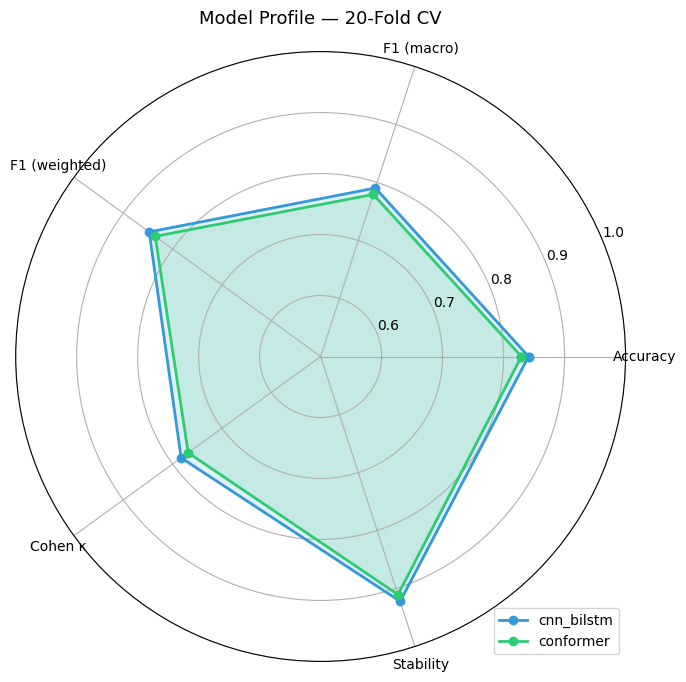


ALL 20-FOLD CV FIGURES SAVED TO GOOGLE DRIVE
  📊 /content/drive/MyDrive/SleepStageNet/enhanced/figures/class_distribution.png
  📊 /content/drive/MyDrive/SleepStageNet/enhanced/figures/conformer_confusion.png
  📊 /content/drive/MyDrive/SleepStageNet/enhanced/figures/cv20_boxplots.png
  📊 /content/drive/MyDrive/SleepStageNet/enhanced/figures/cv20_confusion_matrices.png
  📊 /content/drive/MyDrive/SleepStageNet/enhanced/figures/cv20_per_class_f1.png
  📊 /content/drive/MyDrive/SleepStageNet/enhanced/figures/cv20_per_fold_metrics.png
  📊 /content/drive/MyDrive/SleepStageNet/enhanced/figures/cv20_radar_profile.png
  📈 /content/drive/MyDrive/SleepStageNet/enhanced/training_curves/cv20_training_curves_avg.png
  📋 /content/drive/MyDrive/SleepStageNet/enhanced/results/cv20_per_fold_results.csv


In [19]:
# ===== 5f-9: Radar chart — overall model profile =====
import matplotlib.pyplot as plt
import numpy as np

# Build radar data: mean metrics per model
radar_metrics = ['test_accuracy', 'test_f1_macro', 'test_f1_weighted', 'test_kappa']
radar_labels = ['Accuracy', 'F1 (macro)', 'F1 (weighted)', 'Cohen κ']

# Add stability metric (1 - coefficient_of_variation on accuracy)
radar_labels.append('Stability')
radar_metrics.append('_stability')

angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for model_name in MODELS_CV:
    vals = []
    res = results_all[model_name]
    for m in radar_metrics:
        if m == '_stability':
            accs = [r['test_accuracy'] for r in res]
            cv = np.std(accs) / np.mean(accs) if np.mean(accs) > 0 else 1
            vals.append(1 - cv)  # higher = more stable
        else:
            vals.append(np.mean([r[m] for r in res]))
    vals += vals[:1]  # close polygon

    ax.plot(angles, vals, 'o-', linewidth=2, label=model_name,
            color=COLORS[model_name], markersize=6)
    ax.fill(angles, vals, alpha=0.15, color=COLORS[model_name])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.set_title('Model Profile — 20-Fold CV', fontsize=13, pad=20)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
fig.savefig(os.path.join(DRIVE_FIG_DIR, 'cv20_radar_profile.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary ──
print("\n" + "=" * 60)
print("ALL 20-FOLD CV FIGURES SAVED TO GOOGLE DRIVE")
print("=" * 60)
for fname in sorted(os.listdir(DRIVE_FIG_DIR)):
    print(f"  📊 {DRIVE_FIG_DIR}/{fname}")
if os.path.isdir(DRIVE_CURVE_DIR):
    for fname in sorted(os.listdir(DRIVE_CURVE_DIR)):
        print(f"  📈 {DRIVE_CURVE_DIR}/{fname}")
print(f"  📋 {DRIVE_RESULT_DIR}/cv20_per_fold_results.csv")